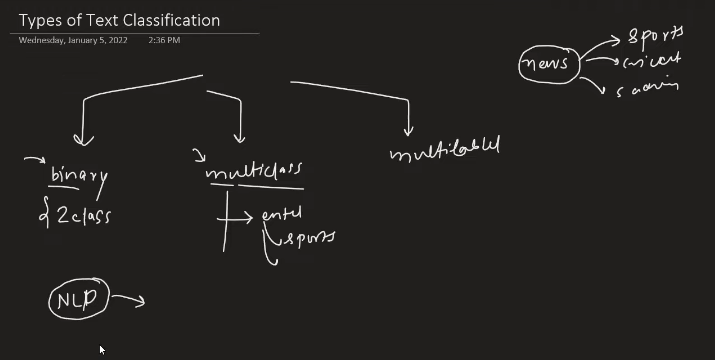

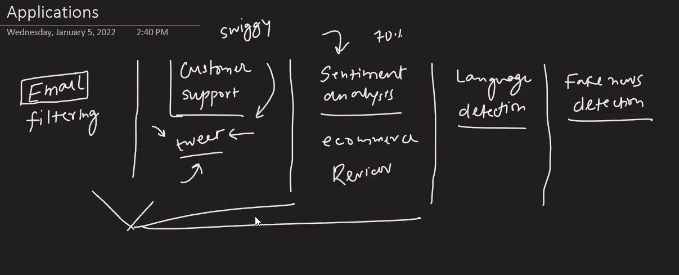

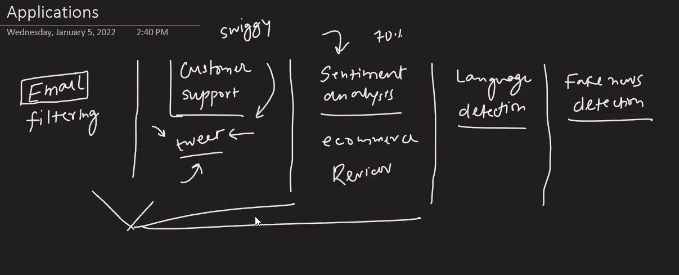

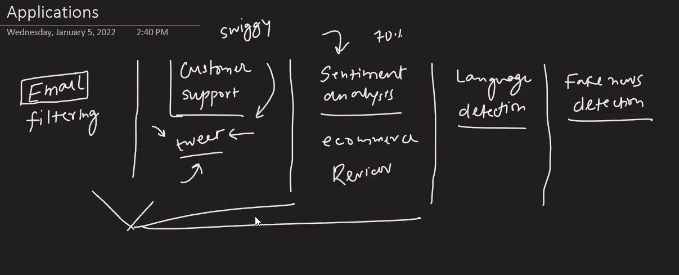

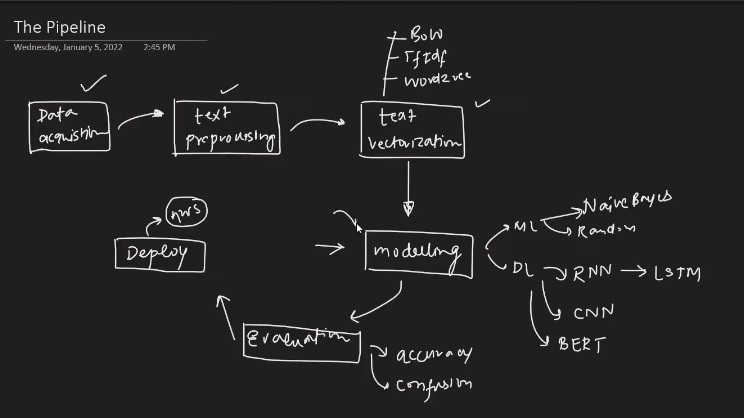

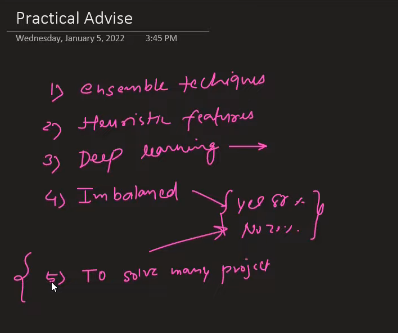



### I. Fundamentals of Text Classification

Text Classification is defined as a type of **supervised machine learning task**. The objective is to take a given input text (which can be a single word, a sentence, or a whole document) and assign it to a specific category or class. It is considered a crucial and widely used topic, underpinning many applications of Machine Learning (ML) and Natural Language Processing (NLP).

**Types of Text Classification**
Text classification tasks are typically divided into three types:
1.  **Binary Classification:** The input belongs to one of only two classes (e.g., an email is Spam or Not Spam).
2.  **Multi-Class Classification:** The input belongs to one of more than two classes (e.g., a news article categorized as Entertainment, Sports, Business, or Politics).
3.  **Multi-Label Classification:** The input can simultaneously belong to multiple categories (e.g., a single news story classified under Sports, Cricket, and a specific player like Sachin).

**Applications of Text Classification**
The underlying logic of text classification is highly useful across various domains. Key applications include:
*   **Email Spam Classification:** Determining if an email’s content indicates it is spam. This was one of the earliest applications of text classification in NLP.
*   **Sentiment Analysis:** Reading text (like a movie review or product review) to determine if the sentiment is positive or negative. This is widely used in e-commerce (like Amazon or Flipkart) to quickly gauge product sentiment from millions of reviews.
*   **Customer Support and Query Routing:** Analyzing customer messages (e.g., tweets or emails) to decide if they are important enough to respond to, or to automatically forward a query to the appropriate team (e.g., Sales or Support).
*   **Language Detection:** Used by tools like Google Translate to first classify the language of the input text before performing translation.
*   **Fake News Detection:** Classifying posts to identify which are fake or genuine.
*   **Content Moderation:** Detecting vulgar content on social media platforms.

### II. The Text Classification Pipeline and General Approaches

A standardized pipeline is typically followed to achieve text classification:
1.  **Data Acquisition:** Obtaining the necessary dataset (e.g., from public sites, APIs, etc.).
2.  **Text Preprocessing:** Cleaning and normalizing the data, as raw data is not clean. Steps include converting text to lower case, stemming/lemmatization, removing stop words, and removing punctuation or HTML tags.
3.  **Text Vectorization:** Converting the textual data into numerical format, which is mandatory for ML/DL algorithms. Techniques used here include Bag of Words, TF-IDF, N-grams, or Word2Vec.
4.  **Modeling:** Applying the chosen ML or DL algorithm (like Naive Bayes, Random Forest, SVM, LSTMs, or BERT).
5.  **Evaluation:** Measuring the performance of the model using various metrics like accuracy score, precision/recall, confusion matrix, or AUC-ROC curve.
6.  **Deployment:** Integrating the finalized model into an existing software system and hosting it (e.g., on a cloud service like AWS) so users can interact with it.

**High-Level Approaches to Text Classification**
There are four broad approaches to implementing text classification:

1.  **Heuristic/Rule-Based Approach ("Jugaad"):** Used when there is insufficient data to train ML or DL models. This involves creating custom rules (e.g., identifying positive and negative words in a text and using their ratio to decide sentiment). This approach is rarely used today unless data is extremely rare or specific.
2.  **Using Existing APIs:** Leveraging ready-made solutions offered by major companies (like Google or AWS) that provide results without requiring custom development. The main positive is ease of use; the main negative is the associated cost per API call.
3.  **Machine Learning (ML) Approach:** The focus of the immediate video. This involves applying standard ML algorithms and customizing the Text Vectorization step (using BoW, N-gram, or TF-IDF) or the Modeling step (using Naive Bayes, Random Forest, or SVM).
4.  **Deep Learning (DL) Approach:** Using advanced techniques like Recurrent Neural Networks (RNNs), LSTMs (Long Short-Term Memory), Convolutional Neural Networks (CNNs), or pre-trained transformer models like BERT. This is planned for a future video.

### III. Machine Learning Implementation Details (with Code Description)

The demonstration uses the IMDB movie review dataset (50,000 reviews), although a subset of 10,000 reviews was used for efficiency.

#### Preprocessing and Preparation
Initial steps involved cleaning the data:
*   HTML tags, stop words, and special characters were removed.
*   Text was converted to lower case.
*   Duplicate reviews (17 were found) were dropped.
*   The target variable (Positive/Negative sentiment) was converted into numerical labels (1/0) using a **label encoder**.
*   The data was split into training and testing sets (e.g., 80% train, 20% test).

#### 1. Bag of Words (BoW) Implementation

The BoW technique was implemented using **`CountVectorizer`**.

| Step | Code/Technique Description | Results/Insights |
| :--- | :--- | :--- |
| **Vectorization** | Used `CountVectorizer`'s **`fit_transform`** function on the training data to create a sparse matrix representation. | The resulting vocabulary size (number of features) was **4800** in the demonstration. |
| **Modeling (Naive Bayes)** | Applied the **`GaussianNB`** algorithm. | Accuracy was calculated to be 66%. |
| **Modeling (Random Forest)** | Applied the **`RandomForestClassifier`**. | Accuracy was significantly better at **84%**. |
| **Optimization (Feature Reduction)** | The process was repeated by limiting the feature space using the `max_features` parameter set to 3000. | This resulted in an accuracy of 83% but created a **much faster model**. |
| **N-gram Extension** | N-grams can be incorporated by setting the **`ngram_range`** parameter (e.g., `(1, 2)` for unigrams and bigrams) within `CountVectorizer`. | Using large N-grams with a wide vocabulary led to a **`MemoryError`** because the feature set (e.g., 600,000 features for bigrams) became too large to allocate memory (e.g., requiring 44 GB). |

#### 2. TF-IDF Implementation

The TF-IDF technique uses the **`TfidfVectorizer`** class.

| Step | Code/Technique Description | Results/Insights |
| :--- | :--- | :--- |
| **Vectorization** | Used `TfidfVectorizer` and called the **`fit_transform`** function on the training data. | TF-IDF is commonly used in information retrieval but can also be applied to text classification. |
| **Modeling** | Applied the **`RandomForestClassifier`**. | Accuracy slightly improved over standard BoW to **84.8%**. |

#### 3. Word2Vec Implementation (Average Word2Vec)

Word2Vec embeds individual words as vectors (e.g., 300 dimensions). To represent a whole document or sentence, the **Average Word2Vec** technique is used, which involves adding all the word vectors in the text together and then dividing by the number of words (averaging the vectors).

| Step | Code/Technique Description | Results/Insights |
| :--- | :--- | :--- |
| **Model Training** | A custom Word2Vec model was trained on the review data. The default vector dimension was **100**. | Training a custom model generally yields better results than using a pre-trained model, provided there is enough data. |
| **Vectorization (Averaging)** | A custom Python function was written to iterate through the words of each review, retrieve its vector from the trained model, calculate the mean of those vectors, and return a single **100-dimensional vector** representing the entire review. | This process was computationally expensive due to the large number of reviews. The resulting training data matrix shape was **(9800, 100)**. |
| **Modeling** | Applied the **`RandomForestClassifier`**. | Accuracy achieved was **70%**. This relatively low score was attributed to using only a subset of the data (10,000 reviews) to train the Word2Vec model. |

### IV. Practical Advice for Text Classification

Based on experience working on multiple text classification projects, the following practical advice is offered:

1.  **Use Combination Techniques:** Sometimes, even seemingly simpler algorithms like Naive Bayes combined with normal vectorization techniques can yield very good results.
2.  **Use Hand-Made Features:** Relying solely on feature engineering is unnecessary. Combining algorithm-generated features with domain expertise or hand-made features often results in better performance.
3.  **Start with Machine Learning (ML):** Do not immediately jump to Deep Learning (DL). Starting with ML provides a better understanding of the data and the problem, which is often lost when moving directly to DL. ML models sometimes even outperform DL models, and implementing DL (importing the model, deploying it) is usually far more complex and time-consuming, possibly not justifying a marginal increase in accuracy.
4.  **Ensure Data Balance:** Always check that the dataset is **not imbalanced** (e.g., 80% in one class and 20% in another). Imbalanced datasets typically yield poor results and require special handling techniques.
5.  **Solve Many Projects:** Gaining experience by solving numerous projects using various datasets is the best way to improve handling future projects.